In [1]:
%matplotlib inline

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import os
from dotenv import load_dotenv

from scipy import stats 

import sys
sys.path.append('../src')
from download_and_extract_data import download_and_extract_data


# for Regressions 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from patsy import dmatrices

In [3]:
##########################################################
# --- RUN THIS CELL BEFORE PROCEEDING WITH THE BELOW --- # 
###### DATA FOLDERS DOWNLOAD AND UNPACK ##################

download_and_extract_data()

##########################################################
# ---                   END                          --- # 
##########################################################

Extracting ../data/raw/eBird_data.7z...
Extracting ../data/raw/weather_data.7z...
Deleting ../data/raw/eBird_data.7z...
Deleting ../data/raw/weather_data.7z...
Data successfully downloaded and extracted.


# Has Bird Migration Timing Shifted in Bulgaria? An Analysis of Seasonal Species and Climate Factors.

Project author: Aneta Gancheva

## Introduction.

### Brief project motivation

Bird migration is a finely tuned ecological process that responds sensitively to seasonal cues. As global climate patterns shift and urban areas expand, many species is be altering their traditional migration routes, timing, and behaviors. (Copernicus programme, 2025)

Three key migratory corridors lie on the territory of Bulgaria and serve both as nesting areas for species arriving from the south and as wintering grounds for species migrating from the north. This project seeks to explore if climate change has influenced these two types of migration through a data-driven lens.

### Bird migration 

Bird migration is an incredible survival strategy — one that enables birds to escape harsh conditions and take advantage of seasonal resources. For species that **winter south** of their breeding grounds, the motivation is simple: food and survival. In colder climates or high altitudes, winters bring low temperatures, snow, and freezing winds. Plants stop growing, insects become scarce due to hibernation or their own migration, and the short daylight hours give birds little time to forage. These conditions make survival extremely challenging, especially for small birds.

For **northbound migration**, the search for suitable breeding grounds is key. Breeding success depends on arriving at the nesting grounds at just the right time. Studies show that birds tend to return at a consistent time every year, with timing being more individual-specific than species-wide. Males often arrive earlier than females to establish territories, and bonded pairs have been observed arriving within days of each other. Correct timing of arrival ensures the availability of nesting places and food, and increases the chance of pairing. (Gilsenan et al, 2020)

Timing matters. An early arrival can extend the breeding season, giving birds a chance for more than one brood. But it also comes with risks — food may not yet be available, and weather may still be unstable. Still, for many species, arriving too late means missing out on prime nesting spots or optimal food supplies for raising chicks.

The north- and southbound migrations are deeply interconnected. What happens in one season influences the next. For example, a late departure from wintering grounds might lead to a delayed arrival at breeding grounds, which in turn affects the success of that season’s offspring. These are called *carry-over effects* — when the conditions or choices during one phase of the annual cycle impact the bird’s performance or survival in the next (Gilsenan et al., 2020).

Furthermore, birds are *endotherms*, which means that they are able to produce a relatively constant body temperature by use of endogenous heat production. Different species have evolved to produce endogenous body temperatures and other adaptive mechanisms that suit their environment, e.g. birds in the desert have adjusted to living and reproducing in arid conditions where the surounding environment is much hotter than their own bodies, while birds in temperate climates need to deal with winters when temperatures fall more than $80^{\circ}$C below their body temperatures. However, rapidly changing climate conditions may not leave much time for birds to develop and evolve to meet challenges such as increasing mean temperature,  lower predictability of climate or more frequent adverse weather events. (Ruuskanen et al., 2020)

### Shifts in bird migration due to climate change

Across the globe, birds are changing their migratory habits in response to climate change. One of the most widely observed shifts is that birds are **migrating earlier** each spring, likely due to the earlier onset of spring, and the rising temperatures. Scientific American reports that spring migration is moving forward by about two days every decade. But even as birds shift their timing, it remains uncertain whether they can keep pace with the accelerating rate of climate change.

Mismatches between bird migration and food availability — such as insects and larvae — are becoming a concern. According to Audubon Vermont, birds traditionally arrive just as insect populations peak, allowing them to rebuild strength and feed their young. But with warmer springs, insects may hatch earlier — and birds may miss the peak entirely, reducing breeding success.

Migration also doesn’t happen in a single flight. Birds rely on **stopover sites**, such as wetlands — to rest and refuel along the way. But changing rainfall patterns are drying out wetlands, while desertification, especially near the Sahara, is consuming critical stopover points. Without these resting areas, many birds face longer flights without food or water, and some may not survive. (Thi, 2024)

Even when birds arrive at the right time, climate unpredictability can bring new dangers. **False springs** — early warm periods followed by sudden frosts — can kill insect larvae, depriving newly arrived birds of food. These unexpected freezes can also harm birds directly if they’ve already started nesting. Species like the Siberian geese are also facing habitat loss as the warming climate causes forests to expand into tundra — reducing access to the rocky, frozen ground they rely on for nesting. (Audubon Vermont, 2025)

Could birds **adapt** at all to these changes? 

Some birds may be showing signs of physical adaptation. A study by Zimova et al. (2021) observed that climate change may be linked to changes like smaller body sizes and longer wingspans, possibly helping birds cool off more efficiently or improve flight. However, adaptations like these evolve slowly, and might not keep pace with the rapid environmental shifts.

Some migrants are somewhat able at adjusting their migration timing. (Marra et al., 2005) But long-distance migrants, who rely on instinct more than local cues, often stick to their internal clocks, even if those timings are now misaligned with the conditions at their destination . For instance, the Afro-Siberian red knot, adapted to tightly synchronized Arctic cycles, appears unable to change fast enough. Once a resilient species that endured millennia of natural climate shifts, it now teeters toward extinction within our lifetime due to human-caused rapid climate change. (YaleEnvironment 360 website, 2025) Another very long-distance migrant that seems to be less affected by the climate change is the arctic tern. This is likely due their long lifespans that allow them to adapt to changing conditions, and incorporate changes in their routes and behaviours. Nevertheless, they still suffer from poorer foraging in their nesting habitats, possibly due to the fact that the population of their pray has been affected by changing climate conditions. (Morten et al., 2023) 

<figure>
  <img src="../pictures/arctic_tern_migration_map.png" alt="The migration route of the arctic tern" style="width:30%">
  <figcaption><b>Fig.1</b> <strong>The arctic tern - a <em>very</em> long distance migratory bird.</strong> <br> The graph depicts the journey of the arctic tern between its breeding grounds in the Arctic and its wintering spot in the Antarctic. This annual journey ensures that the tern sees two summers per years and is speculated to be the creature on the planet that sees the most daylight. (Arctic tern wikipedia page, 2025) <br> Source link: https://www.animalfunfacts.net/waders/1587-arctic-tern.html </figcaption>
</figure>

Climate change also affects autumn migration. Warmer winters are leading some birds to delay or even **cancel migration**. According to WBMD (2007), this can be dangerous when the weather suddenly turns. Meanwhile, birds that remain in the area year-round benefit from mild conditions — they breed earlier and may claim the best nesting cavities or feeding grounds before migratory species return. Moreover, facing changing climate, some non-migratory birds do permanent moves to areas that match their preferred habitat more. This creates competition, especially if food is limited. 

Finally, weather plays a major role in the actual journey. A study by Byrd et al. (2024) found that the best predictors of spring departure in Dark-eyed Juncos were weather variables — especially average nightly wind direction and a combined metric of humidity and temperature. This suggests that while long-term climate sets the stage, short-term weather conditions could also determine the exact timing of migratory movements.

### Is climate the only consideration for migration timing?

We have so far discussed observed possible dependencies between various factors and the timing of bird migration, but how do birds know when to begin migrating? Is it that they simply follow weather cues? 

People have kept migratory birds as pets in the past, and have noticed a strange behaviour, leading to the $1707$ coin of the term **Zugunruhe** - an inborn migratory urge, during spring and fall. The term is derived from the German words "Zug" (move, migration) and "Unruhe" (restlessness).

Changing daylight length and food availability are thought to strongly influence the onset of Zugunruhe, because birds possess internal biological clocks, which are tuned to environmental signals, as well as the clocks of other nearby birds. (Cassone, 204) However, there are also theories that Zugunruhe may be caused by hormonal changes, or other inheritted genetic mechanisms. (Wikipedia, 2025; Justen and Delmore, 2022) 

Below is a sample visual depiction of Zugunruhe from research. 

<figure>
  <img src="../pictures/individual_Zugunruhe.png" alt="Individual Zugunruhe during migratory season" style="width:30%">
  <figcaption><b>Fig.2</b> <strong>Individual Zugunruhe measured for a sample of willow warblers during migratory season.</strong> <br> The graph depicts the individual Zugunruhe curves of a sample of willow warblers, observed during the migratory season. Onset has been normalized, so all begin at origin of x-axis. Zugunruhe is the restlessness during night time measured in relative terms between the individuals (so, in arbitraty units). We can see that the Zugunruhe reaches a maximum at around the 40-th day, and then gradually wanes. This coincides, in general terms, with the actual pattern of migration. <br> Source link: https://ntrs.nasa.gov/api/citations/19720017432/downloads/19720017432.pdf </figcaption>
</figure>

So it's worth mentioning that although climate and weather have been found to serve as strong predictors of migration timing, there are further considerations that capture the full magic of bird behaviour and migration.

### How do birds know where to go? 

There are flocking **day migrants** - birds that fly in flocks, often in the famous energy-efficient V-shape.  Day migrants are taught to rely heavily on the leader's orientation skills. They possibly use the sun as a celestial cue, large-scale landmarks such as coastlines, and locally learned landmarks to e.g. orientate to the exact nesting location within a certain city. (Liedvogel and Delmore, 2018)

This is not possible for **night-migrating** birds. Usually small songbirds and small land birds, night migrants travel in the cover of the night, avoiding predators, and making use of cooling during the nighttime.  A migrating bird produces a huge amount of excess heat that needs to be released.  Most of the heat is lost from the unfeathered legs.  The colder the air temperature, the more quickly that heat can be dumped. Additionally, many cues are unavailable for night travelers, but they possibly rely more on the stars and connected sun position cues such as the skyline polarization pattern. Most impressive is that night migrants' sense of direction relies exclusively on inherited information, especially true for first time night migrants.(Liedvogel and Delmore, 2018)

Both types of migrants also rely on their **inner compasses** and utilize the Earth’s magnetic field. Some species make use of the magnetite in their beaks, while the Smithsonian website informs researchers have found out that others may actually *see* the magnetic field itself. Forbes (2018) summarizes that this *magnetoreception* ability is due to a special protein available in the eyes of birds, and that it is found to be increasingly produced near migration times in some migratory species. 

### Via Pontica, Via Balkanica, Via Aristotelis

A **flyway** is the flight path that is used by large numbers of migratory birds traveling between their breeding grouds and their overwintering locations. Some birds travel the entire flyway length through continents and across oceans, while for other species the entire bi-annually traversed route is only a part of the flyway.

Classifications of flyways vary, but they could be generized in a few main ones, as shown in the diagram below.

<figure>
  <img src="../pictures/Flyways_world.png" alt="Main flyways in the world" style="width:80%">
  <figcaption><b>Fig.3</b> <strong>Main flyways in the world.</strong> <br> <ul> <li>Pacific, Central and Altlantic Americas Flyways, part of the <strong>Americas Flyway System</strong></li> <br><li> East Atlantic, Black Sea - Mediterranean and East Asia - East Africa Flyways, part of the <strong>African - Eurasian Flyway System</strong> </li> <br> <li>The Central Asia Flyway </li> <br> <li>The East Asia - Australasia Flyway </li> <br> <li>Marine Flyways</li> <br> Source link: https://datazone.birdlife.org/about-our-science/flyways </figcaption>
</figure>

Bulgaria falls into the area of the African - Eurasian Flyway system, and consists of three main flyways.

<figure>
  <img src="../pictures/via_pontica_within_BG.png" alt="Flyways in Bulgaria" style="width:50%">
  <figcaption><b>Fig.4</b> <strong>Flyways in Bulgaria.</strong> <br> <ul> <li><strong>Via Aristotelis</strong>: the flyway of western Bulgaria. Named after Aristotle who first noted the existence  of this flyway.</li> <br> <li><strong>Via Balcanica</strong>: the flyway of central Bulgaria, which crosses through the Balkan mountains.</li> <br> <li><strong>Via Pontica</strong>: the flyway of eastern Bulgaria. Named after an ancient Roman road which spanned through the territories of nowadays Romania, Bulgaria and Turkey, along the coast of the Black Sea. </li> <br> This graph is taken out of the below cited Bulgarian research paper and depicts the numbers of soaring spring migrants in Bulgarian air space observed in certain viewpoints, size of the circle corresponding the number of observed soaring migrants. The graph hints to the importance of Via Pontica as the most heavily used flyway in Bulgaria. Source link: https://www.researchgate.net/publication/270049408_Migration_of_Soaring_Birds_over_Bulgaria </figcaption>
</figure>

**Via Pontica** is actually part of what is often considered the second most important flyway in Europe - the Mediterranean/Black Sea Flyway. It is thought that up to $80\%$ of the total European white stork population, (BSPB, 2025) and a speculated $100\%$ of the Great White pelican population passes along the Via Pontica migration route (BSPB, 2023). This fascinating flyway is attracting birdwatchers from around the world, with many international specialized birdwatching tours focusing on the region of Burgas, as for example the Poda Protected Area wetlands. (Poda Protected Are Wikipedia page, 2025)

***

Now that we’ve taken a closer look at how and why birds migrate — and how climate change may be throwing a wrench into those carefully timed journeys — it’s time to bring the focus back to the project itself. Along the way, we also touched on a few fascinating side topics, like the incredible journey of the Arctic tern, the phenomenon of Zugunruhe, and how birds navigate. These insights help paint a fuller picture of the complexity and fragility of migration.

With that context in mind, we will proceed to explore whether **rising temperatures**, **shifting rainfall**, or **more frequent extreme weather** might be changing the way birds move through the region. The following section introduces the species we'll focus on, the data we’ll be working with, and how we plan to connect the dots between climate patterns and migration behavior.

## Data acquisition, cleaning and preprocessing

All data description, acquisition, cleaning and preprocessing has been done in a separate notebook. Please access directly with the link below.  

[Go to Data acquisition, cleaning and preprocessing notebook](data_acquisition_cleaning_and_preprocessing.ipynb)

Necessary functions described in this euxillary notebook have been transferred to the ```../src/``` folder ready for import.

## Exploratory data analysis and feature engineering

Exploratory data analysis in combination with feature engineering has been also discussed in a separate notebook. Feature engineering has been combined with the exploratory data analysis, as meaningful new features have been discovered through EDA, as well. Although the previous chapter also incorporates some features engineering (e.g. creation of the ```wet_day```, ```snow_day``` etc features), these are not yet *final* features I will need for regression. Please access the notebook directly with the link below.

[Go to Exploratory data analysis and feature engineering notebook](exploratory_data_analysis_and_feature_engineering.ipynb)

As in the previous section, all necessary functions from this notebook are ready for import from ```../src/```. Through these functions data is prepared for the regression analysis below.

## Hypotheses testing 

### The regressions - summary 

#### Linear regression

Linear regressions tests whether there is a **linear** relationship between a dependent variable, and independent variables which will be its predictors.

So, given a data set of $n$ observations, and $p$ predictors: $ \{ y_i, x_{i1}, x_{i2}, \cdots x_{ip} \}_{i=1}^{n} $, the linear regression assumes a linear relationship between the dependent variables and the vector of its predictors. So for $p=2$ predictors, and $n$ observations, our vector notation of this will be:

$$ \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix} = \begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ 1 & x_3 \\ \vdots & \vdots \\ 1 & x_n \end{pmatrix} \begin{pmatrix} \beta_0 \\ \beta_1 \end{pmatrix} + \begin{pmatrix} \epsilon_1 \\ \epsilon_2 \\ \epsilon_3 \\ \vdots \\ \epsilon_n \end{pmatrix}  $$

, where $\epsilon_i$ denotes **disturbance** (error) - an unobserved random variables that adds noise to the linear relationship. 

In matrix notation the above will be: 

$$ y = X\beta + \epsilon $$

So, if we have a prediction after running the regression of the form (hat denotes predicted variables): 

$$ \hat{y} = X\hat{\beta} $$

However, a straight line does not necessarily fit the data perfectly. $\hat{\beta}$ is s.t. the residual sum of squares is minimized, i.e. the sum of squared distances between observed and predicted dependent variables ( $\sum_{i=1}^n (y_i - \hat{y}_i)^2 $ ) must be minimal, i.e. that $\hat{y}$ is the best linear fit to $y$. 

Deote that $ y - \hat{y} = X\beta + \epsilon - X\hat{\beta} = \hat{\epsilon} $

Therefore:

$$ \hat{\epsilon}^T\hat{\epsilon} = (y - X\hat{\beta})^T(y - X\hat{\beta}) = y^Ty - 2\hat{\beta}^TX^Ty + \hat{\beta}^TX^TX\hat{\beta} $$

To minimize this we take the first derivative w.r.t. $\hat{\beta}$ and set it to zero: 

$$ \frac{\partial \epsilon^T\epsilon}{\partial \hat{\beta}} = - 2X^Ty + 2X^TX\hat{\beta} = 0 $$

So, if we have a prediction after running the regression of the form (hat denotes predicted variables): 
$$ X^Ty = X^TX\hat{\beta} $$

So,  

$$ X^T(y-X\hat{\beta}) = \vec{0} $$, meaning that $X$ and $\hat{\epsilon}$ are orthogonal. 

Let's denote as **total sum of squares (TSS)** the sum of distances between observed dependent variables and the overall mean: 

$$ \text{TSS} = \sum_{i=1}^{n} (y_i - \bar{y})^2 $$

This is a quantification measure of how much each of the dependent variable observations vary from their mean. It could be thought as the "total variance" of the dependent variable.

By adding and subtracting $\bar{y}_i$, we get: 

$$ y_i - \bar{y} = (\hat{y}_i - \bar{y}) + (y_i - \hat{y}_i) $$

, so rewriting the above sum gives us: 


$$\begin{align} 
\sum_{i=1}^{n} (y_i - \bar{y})^2 & = \sum_{i=1}^{n} (\hat{y}_i - \bar{y}) + y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (\hat{y}_i - \bar{y}) + \hat{\epsilon}_i)^2 = \\ 
& =  \sum_{i=1}^{n} ( (\hat{y}_i - \bar{y})^2 +  2\sum_{i=1}^{n} (\hat{\epsilon}_i(\hat{y}_i - \bar{y}) + \sum_{i=1}^{n}(\hat{\epsilon}_i)^2 = \\
& =  \sum_{i=1}^{n} ( (\hat{y}_i - \bar{y})^2 + \sum_{i=1}^{n}(\hat{\epsilon}_i)^2 + 2(\hat{\beta}_0 - \bar{y})\sum_{i=1}^{n}(\hat{\epsilon})^2 + 2(\hat{\beta}_1)\sum_{i=1}^{n}(\hat{\epsilon}_1x_{i1})^2 + \cdots + 2(\hat{\beta}_p)\sum_{i=1}^{n}(\hat{\epsilon}_1x_{ip})^2 = \\
& =  \sum_{i=1}^{n} ( (\hat{y}_i - \bar{y})^2 + \sum_{i=1}^{n}(\hat{\epsilon}_i)^2 
\end{align}$$

, due to orthogonality. 


Therefore we can denote the above that **TSS** = **ESS** + **RSS**, where ESS=$ \sum_{i=1}^{n} ( (\hat{y}_i - \bar{y})^2$, the explained sum of squares, i.e. the variation that we have managed to explain through regression, and RSS=$ \sum_{i=1}^{n}(\hat{\epsilon}_i)^2$, the unexplained variation. 

Taking the ratio: 

$$ \frac{\text{ESS}}{\text{TSS}} = 1 - \frac{\text{RSS}}{\text{TSS}} = \frac{\sum_{i=1}^{n}(\hat{\epsilon}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = R^2 $$

Thus, $R^2$ is the total variation explained by our regression. 

This is a metric that we will examine when running our regressions. 

To account for the phenomenon that $R^2$ is automatically increasing when independent variables are added to the model, the adjusted $R^2$ was developed, which penalizes the inclusion of irrelevant independent variables.

Another metric provided by the regression analysis output is the F-statistic: whether the regression model provides a better fit to the data than a model that contains no independent variables (intercept only), by comparing if the variances among the two models are significantly different. If the p-value of the F-statistic is less than the significance level we have defined, we can reject the F-test null hypothesis that all coefficients of the regression are simulteneously equal to zero at this significance level.

Let's now present the Linear Regression assumptions.

##### Assumptions 

Presented in this picture are the assumptions behind the linear regression. 

<figure>
  <img src="../pictures/LR_assumptions.png" alt="Illustration of LR assumptions" style="width:80%">
  <figcaption><b>Fig.5</b> <strong>Illustration of LR assumptions - explained in more detail below. <br> Source link: https://www.geeksforgeeks.org/machine-learning/assumptions-of-linear-regression/ </figcaption>
</figure>



- **Linearity** assumes a linear relationship between the dependend and independent variables
  * this could be verified by a plot
    
- **Homoscedasticity of Residuals** assumes that residuals' variance does not depend on the fitted values
  * this could be verified by a residuals vs fitted plot
    
- **Multivariate Normality** assumes that residuals follow a normal distribution
  * this could be verified by a Quantile-Quantile plot
    
- **Independence of Errors** assumes that the residuals are not correlated with one eachother
  * this could be verified by a Durbin–Watson test
    
- **Lack of Multicollinearity** assumes that independent variables are not highly correlated with each other
  * this could be verified by calculating a Variance Inflation Factor for each independent variable

- **Absence of Endogeneity** assumes that independent variables in the regression model should not be correlated with the errors
  * this could be verified through a plot

Let's discuss briefly the tests suggested:

- The **Quantile-Quantile plot** is used to see if a dataset follows a normal distribution. It works by comparing the quantiles of the residuals to the quantiles of the normal distribution.

- The **Durbin–Watson test** statistic $d$ for $T$ observations is $ d = \frac{\sum_{t=2}^T (\epsilon_t - \epsilon_{t-1})^2}{\sum_{t=2}^T \epsilon_t} $, where $\epsilon_t$ are the residuals. It tests against a null hypothesis of no auto-correlation. If autocorrelation exists, then $ \epsilon_{t} = \rho\epsilon_t $, where $\rho$ is the coefficient of autocorrelation. Then, $ d = \frac{\sum_{t=2}^T (\epsilon_t)^2 + \sum_{t=2}^T (\epsilon_{t-1})^2 - 2\sum_{t=2}^T(\epsilon_t-\epsilon_{t-1})}{\sum_{t=2}^T (\epsilon_t)^2} \approx 2(1 - \frac{2\sum_{t=2}^T(\epsilon_t-\epsilon_{t-1})}{\sum_{t=2}^T (\epsilon_t)^2})$. Then, Gujarati (2003) proceeds to define a correlation coefficient $\hat{\rho} = \frac{2\sum_{t=2}^T(\epsilon_t-\epsilon_{t-1})}{\sum_{t=2}^T (\epsilon_t)^2}$ citing Prais and Houthakker (1956), which gives $ d = 2(1-\hat{\rho} $, meaning that with zero autocorrelation the D-W test statistic will be around $2$, and $ d\approx 0$ for positive autocorrelation, $d \approx 4$ for negative autocorrelation.

- The **Variance Inflation Factor** for the $j$th predictor is denoted as $ \text{VIF}_j = \frac{1}{1-R_j^2} $, where $R_j^2$ is the $R^2$ from regressing the $j$th predictor on the remaining predictors. $ \text{VIF} \approx 1 $ denotes no multicollinearity present. 


##### Formulation of hypothesis 

Let's get back to our data now and formulate a hypothesis. 

As already discussed from the assumptions, we do not want that the independent variables are highly correlated with eachother. However, weather events are complex, and unfortunately I have no idea *how weather works*. I could safely regard that weather events are heavily correlated, as an event in a previous period may lead to an event in the next period, as for example cold fronts usually lead to heavy rain and thunderstorms (OpenOregon website, 2025). Therefore, I will *assume* that the best approach is to integrate my weather events, that is a combination of rain, thunderstorm, gale, fog and/or hail, into one "extreme weather" frequency independent variable of the week *before* arrival, and further (boldly) *assume* it is sufficiently independent from the temperature in the season *before* the arrival week. 

What is the logic here? 

As already mentioned, birds aim for favourable weather conditions in the arriving destination, regardless of that being to breed in the summer, or to forage for food in the winter. Therefore, the weather in the previous season may *trigger* birds to proceed to their final destination. However, severe weather events en route, i.e. in a short-term previous period may *hinder* birds to arrive on time. As for instance, Panuccio et al. (2018) report that birds actively avoid flying into fogs, while Van den Broeke and Gunkel (2020) have found out that bird migration could be hindered by thunderstorms and heavy winds, especially in the fall. 

Therefore, it makes sense to do an *extreme weather* integration over **fog**, **gale** and **thunder** to account for these findings. The other predictor will be temperature difference from baseline in the previous season, which supports findings by e.g. The Scientific American (2025) that warm weather triggers earlier arrivals and later departures. 

Thus, I *expect* that arrival week will have a positive correlation with extreme weather event frequency in the prior week (later arrival), and a negative one with higher difference from baseline temperature in previous season (earlier arrival), while the opposite will be expected for departure weeks. 

Let's then now build two sets of hypotheses: 

**Arrival** 

$H_{10a}$: There is no dependence of extreme weather and temperature on arrival 
$H_{11a}$: There is dependence of extreme weather and temperature on arrival

**Departure** 

$H_{10d}$: There is no dependence of extreme weather and temperature on arrival 
$H_{11d}$: There is dependence of extreme weather and temperature on arrival


#### Linear Mixed effects regression 

Continuing from the prior discussion, we have no right to consider that all birds respond the same to these weather conditions. As discussed in the Introduction, some species are far more adaptable than others. 

Therefore, this provides sufficient ground to consider a mixed effects linear model. Mixed effects models incorporate a fixed effect, as well as random effects. These models *assume* that data is grouped in higher level categories. 

Then we amend our linear regression the following way: 

$$ y = X\beta + Zu + \epsilon $$

, where $Zu$ represents $q$ random effects over $J$ groups, or alternatively written: 

$$ y_{ij} = \beta_0 + \beta_1x_{ij1} + \cdots u_{j} + \epsilon_{ij} $$ 

,where this is the observed dependent variable for observation $i$ in group $j$ and $u_{j}$ is the random effect for that group.

##### Assumptions 

As we would have already seen the assumptions of this model from the fixed-effects Linear Regression, there a few other checks (taken from Geeks for Geeks) that could be incorporated: 

- **Likelihood Ratio Test** which will test whether adding random effects significantly improves the model. In Python ```statsmodels``` this is done similarly to a Chi-squared test (which tests if a categorical variable's distribution is different than expected). The null hypothesis that variance of the random effects is zero (i.e. random effects do not bring explanatory power).  
- **AIC** (Akaike Information Criterion) which penalizes model complexity, with lower values indicating a better model fit. Lower value is better. Used to compare between models, not as a standalone.
- **BIC** (Bayesian Information Criterion) which acts the same as AIC but penalty is stronger. Lower value is better. 

##### Formulation of hypothesis 

The hypotheses will be the same as with the fixed-effects linear regression, but accounting for random per-species effect. 

**Arrival** 

$H_{20a}$: There are no significant differences among species in arrival week 

$H_{21a}$: There are significant differences among species in arrival week

**Departure** 

$H_{20d}$: There are no significant differences among species in departure week

$H_{21d}$: There are significant differences among species in departure week


<!-- #### Logistic regression should I have time


##### Assumptions 


##### Formulation of hypothesis -->

#### Data preparation 

In [4]:
# Load dataframes from EDA notebook 

dataframe_for_analysis_summer_breeders = pd.read_csv('../data/dataframe_for_regression_summer.csv')
dataframe_for_analysis_winter_residents = pd.read_csv('../data/dataframe_for_regression_winter.csv') 
dataframe_for_analysis_all_migrants = pd.read_csv('../data/dataframe_for_regression_merged.csv')

#### Testing the hypotheses

Therefore I have constructed a single function that runs all three types of regressions and their adjacent assumption tests, called ```regression_and_tests```. Then I will proceed to test the above hypotheses about my data.

In [5]:
def run_regression_and_tests(
    df: pd.DataFrame,
    formula: str,
    model_type: str = "ols", # or "mixed"
    group_col: str | None = None
):
    """
    Runs regression analysis (OLS or Mixed Effects) with full assumption checks.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataframe containing dependent and independent variables.
    formula : str
        A formula string, e.g. 'arrival_week ~ extreme_weather + temperature'.
    model_type : str, optional
        Type of model to fit: "ols" (default) or "mixed".
    group_col : str, optional
        Column name for grouping in mixed-effects models (e.g. 'species').

    Returns
    -------
    results : statsmodels results object
        Fitted regression model results.
    """

    # ---- Fit Model ---- #
    if model_type == "ols":
        model = smf.ols(formula=formula, data=df).fit()
    elif model_type == "mixed":
        if group_col is None:
            raise ValueError("group_col must be provided for mixed effects model.")
        model = smf.mixedlm(formula, df, groups=df[group_col]).fit()
    else:
        raise ValueError("model_type must be 'ols' or 'mixed'.")

    print(model.summary())

    # ---- Diagnostics for OLS ---- #
    if model_type == "ols":
        residuals = model.resid
        fitted = model.fittedvalues

        # Linearity: Residuals vs Fitted
        plt.scatter(fitted, residuals, alpha=0.7)
        plt.axhline(0, color="red", linestyle="--")
        plt.xlabel("Fitted Values")
        plt.ylabel("Residuals")
        plt.title("Linearity & Homoscedasticity Check")
        plt.show()

        # Normality: QQ Plot
        sm.qqplot(residuals, line="45", fit=True)
        plt.title("QQ Plot of Residuals")
        plt.show()

        # Durbin-Watson Test (Independence)
        dw_stat = durbin_watson(residuals)
        print(f"Durbin-Watson statistic (Independence of Errors): {dw_stat:.3f}")

        # Multicollinearity: VIF
        y, X = dmatrices(formula, data=df, return_type="dataframe")
        vif_data = pd.DataFrame()
        vif_data["Variable"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        print("\nVariance Inflation Factor (Multicollinearity):")
        print(vif_data)

    # ---- Diagnostics for Mixed Effects ---- #
    if model_type == "mixed":
        print("\nModel Fit Criteria (Lower is Better):")
        print(f"AIC: {model.aic:.3f}")
        print(f"BIC: {model.bic:.3f}")

        # Likelihood Ratio Test (compare with OLS as baseline)
        ols_model = smf.ols(formula=formula, data=df).fit()
        lr_stat = 2 * (model.llf - ols_model.llf)
        lr_df = model.df_modelwc - ols_model.df_model
        lr_pval = stats.chi2.sf(lr_stat, lr_df)
        print(f"\nLikelihood Ratio Test for Random Effects:")
        print(f"Chi2({lr_df}): {lr_stat:.3f}, p = {lr_pval:.4f}")

    return model

##### Linear Regression 

**Arrival set of hypotheses for merged dataframe as same effect expected for both types of migrants**

$H_{10a}$: There is no dependence of extreme weather and temperature on arrival 

$H_{11a}$: There is dependence of extreme weather and temperature on arrival

I will test these for summer migrants.

                            OLS Regression Results                            
Dep. Variable:           arrival_week   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     5.307
Date:                Thu, 21 Aug 2025   Prob (F-statistic):            0.00548
Time:                        14:16:30   Log-Likelihood:                -650.65
No. Observations:                 280   AIC:                             1307.
Df Residuals:                     277   BIC:                             1318.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

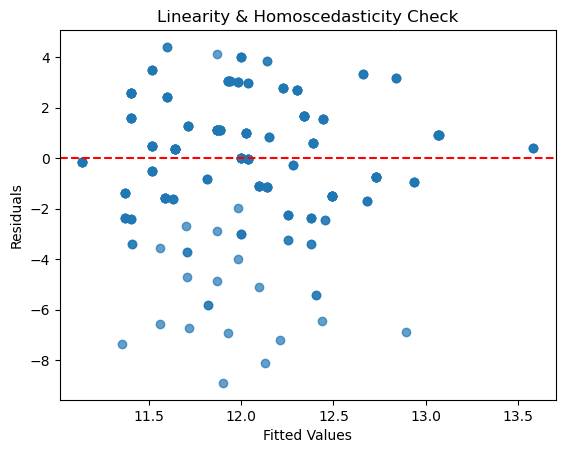

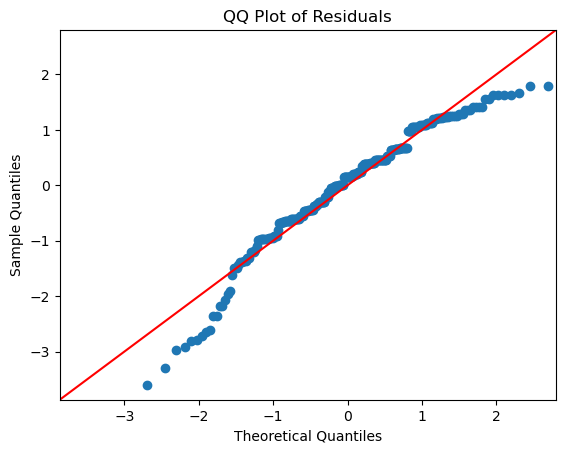

Durbin-Watson statistic (Independence of Errors): 0.611

Variance Inflation Factor (Multicollinearity):
                             Variable       VIF
0                           Intercept  8.751295
1    arrival_aggregate_prev_week_freq  1.001342
2  arrival_week_temp_diff_prev_season  1.001342


In [6]:
ols_arrival_summer = run_regression_and_tests(
    dataframe_for_analysis_summer_breeders,
    formula="arrival_week ~ arrival_aggregate_prev_week_freq 	+ arrival_week_temp_diff_prev_season",
    model_type="ols"
)

Residuals plot seems to point at heteroskedasticity evident from the fan shape (spread increases as fitted values increase). Also, they do not seem to follow a normal distribution, deviating from the $45$-degree line on the Q-Q plot, especially at the tails. 

The Durbin-Watson statistic is less than $2$, suggesting possible positive auto-correlation of the residuals. 

VIF is roughly $1$ for the two predictors, which is due to the possible lack of correlation between them. 

Now, let's have a look at some of the other test statistics provided by the model. 

First of all, $R^2$ points to extremely little variance being expalined by the model - less than $4\%$. From the F-statistic's very low p-value, we can (at the $5\%$ significance level) reject the null hypothesis that all coefficients of the regression are simulteneously equal to zero. 

The temperature difference in previous season predictor has a p-value above the significance level threshold, so we cannot reject the null hypothesis that the true coefficient is zero. For the weather event aggregate frequency in the previous week, we have a positive coefficient and a p-value below the $5\%$ significance level, so we can reject the null that its true coefficient is zero. 

This suggests that with every unit increase in extreme events frequency, arrival weeks will shift forward by slightly more than $10$. Is this reasonable? Not really, as frequency is by definition capped at $1$, therefore increases in frequency will be much smaller than that, if any occur. Nevertheless, the relationship between frequency of extreme weather events in the previous week and arrival week is positive. 

Finally, the intercept of around $11$ suggests arrival week for summer breeders will be at around $11$ when the predictors are zero. 

**Departure** 

$H_{20d}$: There are no significant differences among species in departure week

$H_{21d}$: There are significant differences among species in departure week

I will test the departure hypotheses on winter residents.

                            OLS Regression Results                            
Dep. Variable:         departure_week   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     4.381
Date:                Thu, 21 Aug 2025   Prob (F-statistic):             0.0234
Time:                        14:16:31   Log-Likelihood:                -58.925
No. Observations:                  28   AIC:                             123.8
Df Residuals:                      25   BIC:                             127.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


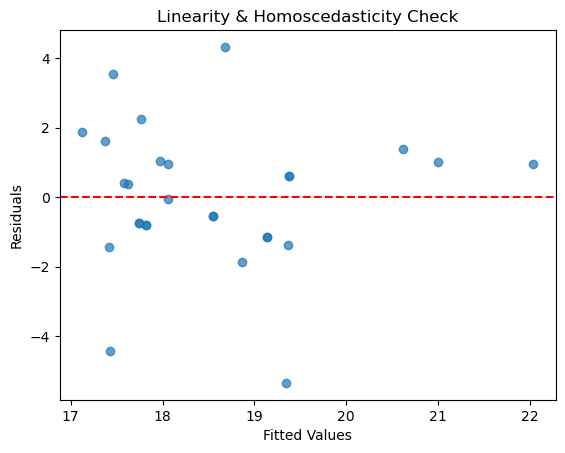

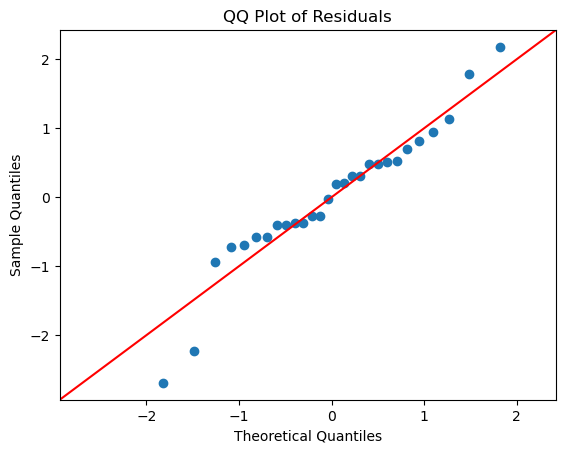

Durbin-Watson statistic (Independence of Errors): 1.345

Variance Inflation Factor (Multicollinearity):
                               Variable       VIF
0                             Intercept  7.770673
1    departure_aggregate_prev_week_freq  1.043501
2  departure_week_temp_diff_prev_season  1.043501


In [7]:
ols_departure_winter = run_regression_and_tests(
    dataframe_for_analysis_winter_residents,
    formula="departure_week ~ departure_aggregate_prev_week_freq + departure_week_temp_diff_prev_season",
    model_type="ols"
)

The Q-Q plot of residuals in this case suggests the distribution of residuals is with fatter tails than the normal one. The residuals' plot against fitted values again suggest heteroskedasticity, due to its not uniformly spread out shape. The Durbin-Watson test statistic is again below $2$ pointing at probable positive autocorrelation. The $R^2$ signifies that only $26\%$ of the variance in data has been explained by the model, which is again a very small proportion. From the F-statistic's p-value we can reject the null hypothesis that all coefficients of the regression are simulteneously equal to zero at the $5\%$ significance level. 

The intercept of slightly below $18$ suggests that if the two predictors are zero,this will be the departure week for winter residents. The previous week aggregate extreme weather events predictor is significant at the $5\%$ level, and has a positive coefficient of around $14,5$, meaning that with the increase of extreme weather events, departure will be delayed. The temperature difference from baseline in the previous season is not significant at the $5\%$ level.

**Mixed effects**

Let's recap we have the following hypotheses:

**Arrival** 

$H_{20a}$: There are no significant differences among species in arrival week 

$H_{21a}$: There are significant differences among species in arrival week

**Departure** 

$H_{20d}$: There are no significant differences among species in departure week

$H_{21d}$: There are significant differences among species in departure week

And run one regression test per group to see how this works.

We begin with checking the arrival hypothesis with winter residents.

In [8]:
formula_winter_arrival = "arrival_week ~ arrival_aggregate_prev_week_freq + arrival_week_temp_diff_prev_season"
df_clean_winter_arrival = dataframe_for_analysis_winter_residents.dropna(subset=["arrival_week", "arrival_aggregate_prev_week_freq", "arrival_week_temp_diff_prev_season"])
model_me_all = run_regression_and_tests(
    df_clean_winter_arrival,
    formula_winter_arrival,
    model_type="mixed",
    group_col="scientific_name"
)

                    Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       arrival_week
No. Observations:         24            Method:                   REML        
No. Groups:               4             Scale:                    1.5684      
Min. group size:          6             Log-Likelihood:           -39.4677    
Max. group size:          6             Converged:                Yes         
Mean group size:          6.0                                                 
------------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------------------
Intercept                          37.141    1.003 37.027 0.000  35.175 39.107
arrival_aggregate_prev_week_freq   -1.982    5.146 -0.385 0.700 -12.068  8.104
arrival_week_temp_diff_prev_season  0.164    0.299  0.549 0.583  -0.421  

We see that the intercept is $37,141$, so if both of our predictor variables are zeros, this will be the arrival week for the winter migrants. Furthermore, the aggregate weather event frequency variable has a negative coefficient, but zero is within its wide confidence interval, and the p-value is above a significance level of $0,05$, so we cannot reject the null hypothesis that this variables has no significance. For the temperature difference in the previous season we get a small positive coefficient, but as zero is again in the confidence interval and the p-value is above the significance interval of $0,05$ we cannot reject the null hypothesis that this predictor has no significance either. The LR ratio test has a p-value below the significance level of $0,05$. 

Nevertheless, the LR test p-value is below the significance level of $0,05$, so this suggests we can reject the hypothesis that there are no significant differences among species in arrival week.

With such a small dataset this is slightly meaningles, but shows a proof of concept that the dataframe can be regressed over. 

In [9]:
formula_summer_departure = "departure_week ~ departure_aggregate_prev_week_freq + departure_week_temp_diff_prev_season"
df_clean_summer_departure = dataframe_for_analysis_summer_breeders.dropna(subset=["departure_week", "departure_aggregate_prev_week_freq", "departure_week_temp_diff_prev_season"])
model_me_all = run_regression_and_tests(
    df_clean_summer_departure,
    formula_summer_departure,
    model_type="mixed",
    group_col="scientific_name"
)

                     Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       departure_week
No. Observations:        246           Method:                   REML          
No. Groups:              41            Scale:                    1.4925        
Min. group size:         6             Log-Likelihood:           -475.7563     
Max. group size:         6             Converged:                Yes           
Mean group size:         6.0                                                   
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                            40.728    0.581 70.155 0.000 39.590 41.866
departure_aggregate_prev_week_freq   -1.733    1.540 -1.125 0.260 -4.752  1.286
departure_week_temp_diff_prev_season -0.145    0.091 -1.601 0

Here, intercept is around $41$, so if the predictors are zero, this will be the summer breeders departure week. The extreme weather events aggregate of the previous week has a small negative coefficient, but its p-value is above our significance level of $0,05$, and zero is in the confidence interval, meaning we cannot reject the null hypothesis that it doesn't bring predictive power. For the temperature difference from baseline of the previous season, we again have a small negative coefficient, and a p-value above the significance level of $0,05$, with zero not within the confidence interval, so we cannot reject the hypothesis that this predictor is not significant at this significance level. 

The chi-squared p-value is at $0$, meaning that we can reject the hypothesis that there are no significant differences among species in arrival week at the $5\%$ condidence level. 

## Conclusive remarks

This marks the (abrupt) conclusion of the project, after presenting four regression examples demonstrating how the produced dataframes can be used.

### Summary of results

Overall, the four models explained only a small fraction of the variance in arrival and departure weeks. Diagnostic plots suggested potential heteroskedasticity and residual autocorrelation, while VIF values indicated low multicollinearity between the two chosen predictors.

Although the results are largely inconclusive, they illustrate the feasibility of producing fully cleaned and regression-ready datasets for further study, leveraging the eBird EBD dataset alongside NOAA weather data.

### Summary of limitations

Using eBird as the sole data source presents challenges, particularly in countries where participation is limited. Checklist-based observations are inherently subject to human bias and prone to errors. Moreover, there are few alternative checklist-type observation sources that could easily complement eBird data.

Satellite data represents a potential avenue for improvement. Such data could track bird migrations directly and provide information about geographical features along migration routes, weather phenomena encountered, and flock responses. Additionally, satellite and GIS data could help infer historical changes in weather, terrain, and human-made constructions—such as wind turbines, tall buildings, or expanding urban areas—all of which could influence migration patterns and warrant further exploration.

Weather data itself can be challenging to interpret without meteorological expertise. It is limited by the number of stations, their spatial coverage, and temporal resolution. Aggregating weather data at the national level may also fail to accurately represent the conditions experienced by birds at specific stopover locations.

Finally, the regression analyses were constrained by limited data, small sample sizes, and assumptions that were necessarily simplified. While these analyses did not produce strong predictive results, the project successfully produced clean, preprocessed data ready for regression. Further work could refine assumptions and potentially reveal more meaningful relationships between variables.

In summary, this project represents a modest but interesting step: a proof-of-concept demonstrating data cleaning, integration, and regression modeling for bird migration studies.

## Works Cited

**for the Introduction**
_____

**Journal Articles and Book Chapters**  
- Cassone, V. M., 2014. “Avian circadian organization: A chorus of clocks,” *Frontiers in Neuroendocrinology*, 35(1), pp. 76–88. doi: 10.1016/j.yfrne.2013.10.002.  
- Marjakangas, E., Johnston, A., Santangeli, A., & Lehikoinen, A., 2024. “Bird species’ tolerance to human pressures and associations with population change,” *Global Ecology and Biogeography*, 33(5). doi: 10.1111/geb.13816.  
- Byrd, A. J., et al., 2024. “Determinants of spring migration departure dates in a New World sparrow: Weather variables reign supreme,” *Ecology and Evolution*, 14(2), p. e10874. doi: 10.1002/ece3.10874.  
- Ruuskanen, S., Hsu, B.-Y., & Nord, A., 2021. “Endocrinology of thermoregulation in birds in a changing climate,” *Molecular and Cellular Endocrinology*, 519, p. 111088. doi: 10.1016/j.mce.2020.111088.  
- Morten, J. M., et al., 2023. “Global warming and arctic terns: Estimating climate change impacts on the world’s longest migration,” *Global Change Biology*, 29(19), pp. 5596–5614. doi: 10.1111/gcb.16891.  
- Michev, T., Profirov, L., Karaivanov, N., & Michev, B., 2012. “Migration of Soaring Birds over Bulgaria,” *Acta Zoologica Bulgarica*, 64, pp. 33–41.  
- Zimova, M., Willard, D. E., Winger, B. M., & Weeks, B. C., 2021. “Widespread shifts in bird migration phenology are decoupled from parallel shifts in morphology,” *Journal of Animal Ecology*, 90(10), pp. 2348–2361. doi: 10.1111/1365-2656.13543.  
- Justen, H., & Delmore, K. E., 2022. “The genetics of bird migration,” *Current Biology*, 32(20), pp. R1144–R1149. doi: 10.1016/j.cub.2022.07.008.  
- Gilsenan, C., Valcu, M., & Kempenaers, B., 2020. “Timing of arrival in the breeding area is repeatable and affects reproductive success in a non-migratory population of blue tits,” *Journal of Animal Ecology*, 89(4), pp. 1017–1031. doi: 10.1111/1365-2656.13160.  
- Thị, N., 2024. “Role of Climate Change in Altering Bird Migration Patterns in Vietnam,” *International Journal of Climatic Studies*, 3(3), Art. no. 3. doi: 10.47604/ijcs.2972.  
- “(Micro)evolutionary Changes and the Evolutionary Potential of Bird Migration,” 2018. In *Fascinating Life Sciences*, Cham: Springer International Publishing, pp. 109–127. doi: 10.1007/978-3-319-91689-7_7.  
- “The influence of climate on the rate and timing of bird migration,” n.d. ResearchGate. doi: 10.1007/s00442-004-1725-x.  

**Websites and Online Sources**  
- Universiteit Leiden, 2024. “Mismatched timing: How climate change challenges bird migration.” [https://www.universiteitleiden.nl/en/news/2024/01/mismatched-timing-how-climate-change-challenges-bird-migration](https://www.universiteitleiden.nl/en/news/2024/01/mismatched-timing-how-climate-change-challenges-bird-migration) (accessed Aug. 2025).  
- Copernicus Climate Change Service, n.d. “Bird Migration.” [https://birdmigration.climate.copernicus.eu/](https://birdmigration.climate.copernicus.eu/) (accessed Aug. 2025).  
- Engain, n.d. “Bird Migration and Climate Change.” [https://www.engain.com/bird-migration-and-climate-change/](https://www.engain.com/bird-migration-and-climate-change/) (accessed Aug. 2025).  
- RSPB, n.d. “Birds and Wildlife: Bird Migration.” [https://www.rspb.org.uk/birds-and-wildlife/bird-migration](https://www.rspb.org.uk/birds-and-wildlife/bird-migration) (accessed Aug. 2025).  
- eBird, n.d. [https://ebird.org/home](https://ebird.org/home) (accessed Aug. 2025).  
- World Migratory Bird Day, 2007. [https://www.worldmigratorybirdday.org/2007/index44cb.html](https://www.worldmigratorybirdday.org/2007/index44cb.html) (accessed Aug. 2025).  
- NEEF, n.d. “How Climate Change is Changing Animal Habits.” [https://www.neefusa.org/story/climate-change/how-climate-change-changing-animal-habits](https://www.neefusa.org/story/climate-change/how-climate-change-changing-animal-habits) (accessed Aug. 2025).  
- Earth Rangers, n.d. “How Do Birds Know When It’s Time to Migrate?” [https://www.earthrangers.com/EN/CA/my-missions/how-do-birds-know-when-its-time-to-migrate/](https://www.earthrangers.com/EN/CA/my-missions/how-do-birds-know-when-its-time-to-migrate/) (accessed Aug. 2025).  
- Smithsonian SSEC, n.d. “How Do Birds Navigate?” [https://ssec.si.edu/stemvisions-blog/how-do-birds-navigate](https://ssec.si.edu/stemvisions-blog/how-do-birds-navigate) (accessed Aug. 2025).  
- Forbes, 2018. “We Finally Know How Birds Can See Earth’s Magnetic Field.” [https://www.forbes.com/sites/trevornace/2018/04/04/we-finally-know-how-birds-can-see-earths-magnetic-field/](https://www.forbes.com/sites/trevornace/2018/04/04/we-finally-know-how-birds-can-see-earths-magnetic-field/) (accessed Aug. 2025).  
- Scientific American, n.d. “Millions of Birds Are Migrating Earlier Because of Warming.” [https://www.scientificamerican.com/article/millions-of-birds-are-migrating-earlier-because-of-warming/](https://www.scientificamerican.com/article/millions-of-birds-are-migrating-earlier-because-of-warming/) (accessed Aug. 2025).  
- Wikipedia contributors, 2025a. “Arbitrary unit,” *Wikipedia*. [https://en.wikipedia.org/w/index.php?title=Arbitrary_unit&oldid=1224364537](https://en.wikipedia.org/w/index.php?title=Arbitrary_unit&oldid=1224364537) (accessed Aug. 2025).  
- Wikipedia contributors, 2025b. “Arctic tern,” *Wikipedia*. [https://en.wikipedia.org/w/index.php?title=Arctic_tern&oldid=1292069043](https://en.wikipedia.org/w/index.php?title=Arctic_tern&oldid=1292069043) (accessed Aug. 2025).  
- Wikipedia contributors, 2025c. “Bird migration,” *Wikipedia*. [https://en.wikipedia.org/w/index.php?title=Bird_migration&oldid=1300021840](https://en.wikipedia.org/w/index.php?title=Bird_migration&oldid=1300021840) (accessed Aug. 2025).  
- Wikipedia contributors, 2025d. “East Atlantic Flyway,” *Wikipedia*. [https://en.wikipedia.org/w/index.php?title=East_Atlantic_Flyway&oldid=1285791353](https://en.wikipedia.org/w/index.php?title=East_Atlantic_Flyway&oldid=1285791353) (accessed Aug. 2025).  
- Wikipedia contributors, 2025e. “Flyway,” *Wikipedia*. [https://en.wikipedia.org/w/index.php?title=Flyway&oldid=1288896046](https://en.wikipedia.org/w/index.php?title=Flyway&oldid=1288896046) (accessed Aug. 2025).  
- BSPB, n.d. “For two years we have been monitoring Vaya’s travels.” [https://bspb.org/en/for-two-years-we-have-been-monitoring-vayas-travels/](https://bspb.org/en/for-two

**for Regressions**
_______________

**Websites and Online Tutorials**  
- Penn State University, n.d. “Multiple Linear Regression.” *STAT 462 Online*. [https://online.stat.psu.edu/stat462/node/132/](https://online.stat.psu.edu/stat462/node/132/) (accessed Aug. 2025).  
- Wikipedia contributors, 2025. “Linear regression,” *Wikipedia*. [https://en.wikipedia.org/wiki/Linear_regression](https://en.wikipedia.org/wiki/Linear_regression) (accessed Aug. 2025).  
- Turing, n.d. “Beginners Guide to Complete Mathematical Intuition Behind Linear Regression Algorithms.” [https://www.turing.com/kb/beginners-guide-to-complete-mathematical-intuition-behind-linear-regression-algorithms](https://www.turing.com/kb/beginners-guide-to-complete-mathematical-intuition-behind-linear-regression-algorithms) (accessed Aug. 2025).  
- Signori, D., n.d. “OLS Lecture Notes.” Simon Fraser University. [https://www.sfu.ca/~dsignori/buec333/lecture%208.pdf](https://www.sfu.ca/~dsignori/buec333/lecture%208.pdf) (accessed Aug. 2025).  
- Statproofbook, n.d. “Multiple Linear Regression - OLS.” [https://statproofbook.github.io/P/mlr-ols](https://statproofbook.github.io/P/mlr-ols) (accessed Aug. 2025).  
- DS100, n.d. “Ordinary Least Squares Regression.” [https://ds100.org/course-notes/ols/ols.html](https://ds100.org/course-notes/ols/ols.html) (accessed Aug. 2025).  
- GeeksforGeeks, n.d. “Assumptions of Linear Regression.” [https://www.geeksforgeeks.org/machine-learning/assumptions-of-linear-regression/](https://www.geeksforgeeks.org/machine-learning/assumptions-of-linear-regression/) (accessed Aug. 2025).  
- Datacamp, n.d. “How to Make a Q-Q Plot in Python.” [https://www.datacamp.com/tutorial/qq-plot](https://www.datacamp.com/tutorial/qq-plot) (accessed Aug. 2025).  
- Zalamsyah, n.d. *Basic Econometrics*, 4th Ed. [http://zalamsyah.staff.unja.ac.id/wp-content/uploads/sites/286/2019/11/7-Basic-Econometrics-4th-Ed.-Gujarati.pdf](http://zalamsyah.staff.unja.ac.id/wp-content/uploads/sites/286/2019/11/7-Basic-Econometrics-4th-Ed.-Gujarati.pdf) (accessed Aug. 2025).  
- Oxford Academic, n.d. “Econometrics: Linear Regression.” [https://academic.oup.com/ej/article-abstract/66/262/322/5259095?redirectedFrom=PDF](https://academic.oup.com/ej/article-abstract/66/262/322/5259095?redirectedFrom=PDF) (accessed Aug. 2025).  
- Penn State University, n.d. “Linear Regression Diagnostics.” *STAT 462 Online*. [https://online.stat.psu.edu/stat462/node/180/](https://online.stat.psu.edu/stat462/node/180/) (accessed Aug. 2025).  
- Open Oregon, n.d. “Weather Processes and Regression Context.” [https://openoregon.pressbooks.pub/earthscience/chapter/15-2-weather-processes/](https://openoregon.pressbooks.pub/earthscience/chapter/15-2-weather-processes/) (accessed Aug. 2025).  
- Panuccio, M., et al., 2019. “Migrating birds avoid flying through areas with high air pollution.” *Animal Flight Research*. [https://animalflight.haifa.ac.il/wp-content/uploads/2015/05/Panuccio2019_Article_MigratingBirdsAvoidFlyingThrou.pdf](https://animalflight.haifa.ac.il/wp-content/uploads/2015/05/Panuccio2019_Article_MigratingBirdsAvoidFlyingThrou.pdf) (accessed Aug. 2025).  
- ZSL Publications, 2022. “Remote Sensing and Bird Migration Studies.” [https://zslpublications.onlinelibrary.wiley.com/doi/full/10.1002/rse2.179](https://zslpublications.onlinelibrary.wiley.com/doi/full/10.1002/rse2.179) (accessed Aug. 2025).  
- GeeksforGeeks, n.d. “Introduction to Linear Mixed Effects Models.” [https://www.geeksforgeeks.org/machine-learning/introduction-to-linear-mixed-effects-models/](https://www.geeksforgeeks.org/machine-learning/introduction-to-linear-mixed-effects-models/) (accessed Aug. 2025).